In [60]:
from pymatgen.core import Structure
import numpy as np
import matplotlib.pyplot as plt 
import math
from pymatgen.analysis.diffraction.xrd import ATOMIC_SCATTERING_PARAMS

In [98]:
#wczytanie pliku CONTCAR (CONTCAR ma pozycje jonów), robi to biblioteka pymatgen
#test1
struct = Structure.from_file("CONTCAR1")
print(f"{struct.composition.formula}")
print(f"{struct.composition.reduced_formula}")


Ce24 Pr8 O60
Ce6Pr2O15


In [62]:
#test2
siatka = struct.lattice #geometria komórki
atomy = struct.sites #rodzaj i położenia atomów
print(atomy[40].specie.Z)
#print(siatka)
#print(atomy)
#d_hkl = siatka.d_hkl((1, 1, 0))
#print(d_hkl)

8


In [63]:
#współczynniki abc dla jonów Ce4+,Pr3+,O2- w formacie [a1, b1, a2, b2, a3, b3, a4, b4, c]
#stałe wzięte z tabel
#http://lampx.tugraz.at/~hadley/ss1/crystaldiffraction/atomicformfactors/formfactors.php
#https://www.researchgate.net/publication/279973413_On_the_atomic_scattering_factor_for_O_2#fullTextFileContent

def atomicfactor(atom,wavelength,sin_theta):
    f_atomic=0;
    if (atom.specie.Z==8):
        wsp=[ 3.75040,2.84294,1.54298,1.62091,16.5151,6.59203,0.319201,43.3486,0.242060]
    elif (atom.specie.Z==58):
         wsp=[19.3881,2.5804,18.2323,0.2078,11.2335,15.1102,1.8398,42.4208,3.2987]
    else: #(atom.specie.Z==59):
         wsp=[21.3727, 2.6452, 19.7491, 0.214299, 12.1329, 15.3230, 0.97518, 36.4065, 1.77132]
    Q=2*2*np.pi/wavelength*sin_theta
    G=(Q/4/np.pi)**2
    f_atomic = (wsp[0] * np.exp(-wsp[1] * G) + wsp[2] * np.exp(-wsp[3] * G) + wsp[4] * np.exp(-wsp[5] * G) + wsp[6] * np.exp(-wsp[7] * G) + wsp[8])
    return f_atomic
    

In [95]:
#ręczne liczenie ze wzorków #https://docs.lammps.org/compute_xrd.html
def CONTCAR2XRD(structure, wavelength,min2theta, max2theta): 
    siatka = structure.lattice #geometria komórki =>z tego gdzie piki
    atomy = structure.sites #rodzaj i położenia atomów =>z tego internywność 
    wyniki =[]
    for h in range(-12,13):
        for k in range(-12,13):
            for l in range(-12,13):
                if h == 0 and k == 0 and l == 0: continue
    
                d_hkl = siatka.d_hkl((h, k, l)) #liczymy odległości międzypłaszczynowe dla rodzin hkl, d_hkl uwzględnia czy struktura regularna/jednoskośna itp.
               
                #prawo Braggów dla każdej z płaszczyzn n*lambda=2*d*sin(theta) dla n=1
                sin_theta = wavelength / (2 * d_hkl)
                if sin_theta > 1: continue
                theta = np.arcsin(sin_theta)
                theta2 = 2 * theta #podwajamy kąt do dyfraktogramu
                if ((theta2 > math.radians(max2theta)) or (theta2 < math.radians(min2theta))): continue #pomijam jak poza zakresem
    
    
                Lp_theta=(1+np.cos(theta2)**2)/(np.cos(theta)*np.sin(theta)**2) #Lorentz polarization factor
                F_hkl = 0 + 0j
                s = sin_theta / wavelength
                f_atomic=0;
                for atom in atomy:
                    
                    #f_atomic=atomicfactor(atom,wavelength,sin_theta)
                    f_atomic=atom.specie.Z
                    xyz = atom.frac_coords
                    #2*pi*i*(h*x + k*y + l*z)
                    faza = 2 * np.pi * (h * xyz[0] + k * xyz[1] + l * xyz[2])
                    F_hkl += f_atomic*np.exp(1j * faza)
                I=Lp_theta*np.abs(F_hkl)**2 #intensywność danego piku
                wyniki.append({"hkl": (h, k, l), "2theta": math.degrees(theta2),"intensity": I})
                
    return wyniki

Text(0, 0.5, 'Intensity (a.u.)')

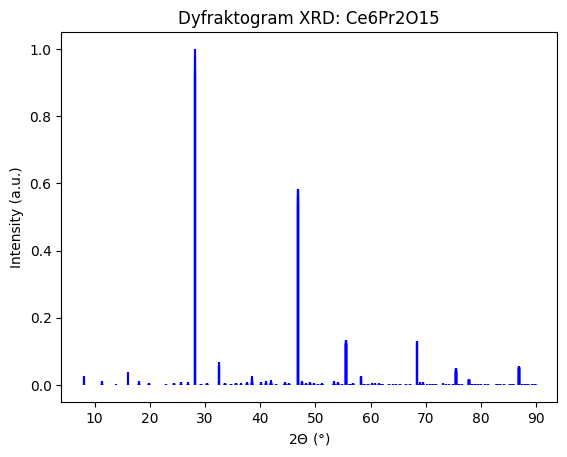

In [79]:
wavelength_K_alpha=1.5418 #lampa anoda Cu, taka chyba u nas na wydziale
struct = Structure.from_file("CONTCAR1")
piki = CONTCAR2XRD(struct,wavelength_K_alpha,0,90)
x = np.array([p["2theta"] for p in piki])
y = np.array([p["intensity"] for p in piki])


#normalizowanie wykresu do max 1
y = np.array(y)
y = y / np.max(y)

plt.vlines( x,0, y, colors='blue', linewidth=1.5)
plt.title(f"Dyfraktogram XRD: {struct.composition.reduced_formula}")
plt.xlabel(r"2$\Theta$ ($\degree$)")
plt.ylabel("Intensity (a.u.)")



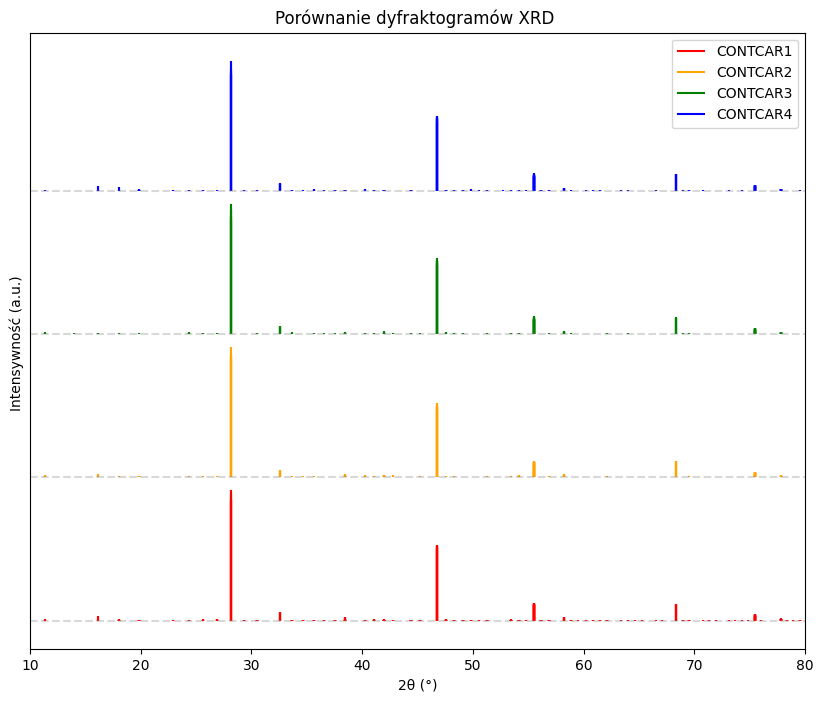

In [80]:
#to co mi wyszło
#wszystko na jeden wyrkes ładnie

def normowanie(y):
    y = np.array(y)
    if np.max(y) == 0: return y
    return y / np.max(y)
struct1 = Structure.from_file("CONTCAR1")
struct2 = Structure.from_file("CONTCAR2")
struct3 = Structure.from_file("CONTCAR3")
struct4 = Structure.from_file("CONTCAR4")
structures = [struct1, struct2, struct3, struct4]
labels = ['CONTCAR1', 'CONTCAR2', 'CONTCAR3', 'CONTCAR4']
#colors = ['#800070','#C71585', '#FF1499', '#FF69B4'] # kolorki
colors = ['red','orange', 'green', 'blue'] # kolorki
plt.figure(figsize=(10, 8))

offset = 1.1  #zeby bylo na jednym wykresie wszystko ale przesuniete

for i, struct in enumerate(structures):
    piki = CONTCAR2XRD(struct, wavelength_K_alpha, 10, 80)
    x = [p["2theta"] for p in piki]
    y = [p["intensity"] for p in piki]
    y_norm = normowanie(y)
    y_shifted = y_norm + (i * offset)

    plt.vlines(x, i * offset, y_shifted, colors=colors[i], lw=1.5, label=labels[i])
    plt.hlines(i * offset, 10, 100, colors='gray', linestyles='--', alpha=0.3)# zero kazdego dyfraktogramu

plt.title("Porównanie dyfraktogramów XRD ")
plt.xlabel("2θ (°)")
plt.ylabel("Intensywność (a.u.) ")
plt.xlim(10, 80)
plt.yticks([])
plt.legend()
plt.savefig("wszystkie_contcars.png")
plt.show()

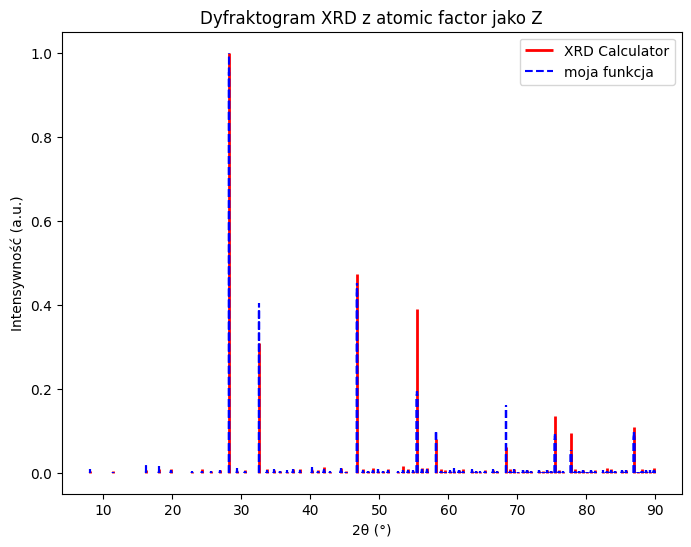

In [96]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

#z gotowej funkcji xrdcalculator
structure = Structure.from_file("CONTCAR1")
wynik_xrd_calculator = XRDCalculator(wavelength='CuKa')
dane = wynik_xrd_calculator.get_pattern(structure)
xx = np.array(dane.x)
yy = normowanie(dane.y)

wavelength_K_alpha=1.5418 #lampa anoda Cu
piki = CONTCAR2XRD(struct,wavelength_K_alpha,0,90)
x=[p["2theta"] for p in piki]
y=[p["intensity"] for p in piki]

y = normowanie(y)





plt.figure(figsize=(8, 6))

plt.vlines(xx, 0, yy, colors='red', lw=2, label='XRD Calculator')
plt.vlines( x,0, y, colors='blue',linestyles='dashed', linewidth=1.5, label='moja funkcja')
plt.title(f"Dyfraktogram XRD z atomic factor jako Z")
plt.xlabel("2θ (°)")
plt.ylabel("Intensywność (a.u.)")
plt.legend()
plt.savefig("z_uwzględnieniem_z.png")
plt.show()


#w mojej funkcji przy koncu 1 pik za niski a 3 nie ma czemu?????////